# Random Imputation - Numerical Values


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [85]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [86]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [87]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
X_train['Age_Imputed'] = X_train['Age']
X_test['Age_Imputed'] = X_test['Age']

In [90]:
X_train['Age_Imputed'][X_train['Age_Imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=0).values
X_test['Age_Imputed'][X_test['Age_Imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state=0).values

In [91]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=0).values

array([20.  , 24.  , 17.  , 30.  , 27.  , 43.  , 34.  , 19.  , 64.  ,
       58.  , 55.  , 50.  ,  4.  , 35.  , 47.  , 44.  , 16.  , 43.  ,
       24.  , 24.  , 35.  , 44.  , 30.  , 38.  , 29.  , 25.  , 24.  ,
        0.67, 28.  ,  2.  ,  6.  , 35.  , 36.  ,  2.  , 23.  , 58.  ,
       28.  , 27.  , 28.  , 22.  ,  3.  , 26.  , 26.  , 29.  , 16.  ,
        3.  , 33.  ,  9.  , 15.  , 20.  , 16.  ,  0.42,  4.  , 19.  ,
       26.  , 18.  , 38.  , 29.  , 51.  , 29.  , 26.  , 18.  , 31.  ,
       23.  , 14.5 , 15.  , 47.  , 31.  , 20.  , 36.  , 16.  , 52.  ,
       22.  , 30.  , 17.  , 45.  , 42.  , 62.  , 20.  , 43.  , 48.  ,
       21.  , 45.  , 48.  , 31.  , 54.  , 30.  , 14.  , 28.  , 25.  ,
       45.  , 25.  , 18.  , 33.  , 47.  ,  2.  ,  7.  , 39.  , 50.  ,
       21.  , 40.  , 34.  , 39.  , 14.  , 48.  ,  7.  , 17.  , 18.  ,
       16.  , 22.  , 27.  , 41.  , 49.  ,  1.  , 21.  , 39.  , 25.  ,
       38.  , 54.  , 19.  , 52.  , 21.  , 27.  , 30.  , 35.  ,  3.  ,
       26.  , 42.  ,

In [92]:
X_train

,Age,Fare,Family,Age_Imputed
331,45.5,28.5000,0,45.5
733,23.0,13.0000,0,23.0
382,32.0,7.9250,0,32.0
704,26.0,7.8542,1,26.0
813,6.0,31.2750,6,6.0
...,...,...,...,...
106,21.0,7.6500,0,21.0
270,NaN,31.0000,0,25.0
860,41.0,NaN,2,41.0
435,14.0,120.0000,3,14.0


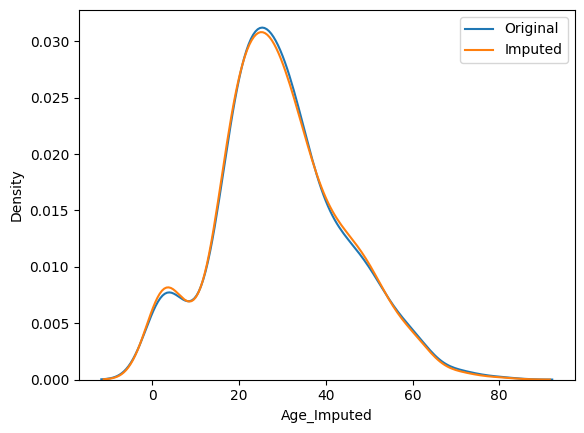

In [93]:
sns.distplot(X_train['Age'], label='Original', hist=False)
sns.distplot(X_train['Age_Imputed'], label='Imputed', hist=False)
plt.legend()

In [94]:
print('Original: ', X_train['Age'].var())
print('Imputed: ', X_train['Age_Imputed'].var())

Original:  210.2517072477438
Imputed:  209.66366977176497


In [95]:
X_train.cov()

,Age,Fare,Family,Age_Imputed
Age,210.251707,75.481375,-6.993325,210.251707
Fare,75.481375,2761.031435,18.599163,62.966016
Family,-6.993325,18.599163,2.830892,-6.091526
Age_Imputed,210.251707,62.966016,-6.091526,209.663670


<Axes: >

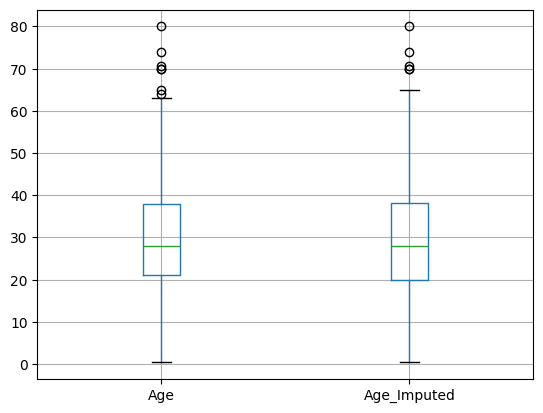

In [96]:
X_train[['Age','Age_Imputed']].boxplot()

In [97]:
X_train['Fare_Imputed'] = X_train['Fare']
X_test['Fare_Imputed'] = X_test['Fare']

In [98]:
X_train['Fare_Imputed'][X_train['Fare_Imputed'].isnull()] = X_train['Fare'].dropna().sample(X_train['Fare'].isnull().sum(), random_state=0).values
X_test['Fare_Imputed'][X_test['Fare_Imputed'].isnull()] = X_train['Fare'].dropna().sample(X_test['Fare'].isnull().sum(), random_state=0).values

In [99]:
X_train

,Age,Fare,Family,Age_Imputed,Fare_Imputed
331,45.5,28.5000,0,45.5,28.5000
733,23.0,13.0000,0,23.0,13.0000
382,32.0,7.9250,0,32.0,7.9250
704,26.0,7.8542,1,26.0,7.8542
813,6.0,31.2750,6,6.0,31.2750
...,...,...,...,...,...
106,21.0,7.6500,0,21.0,7.6500
270,NaN,31.0000,0,25.0,31.0000
860,41.0,NaN,2,41.0,46.9000
435,14.0,120.0000,3,14.0,120.0000


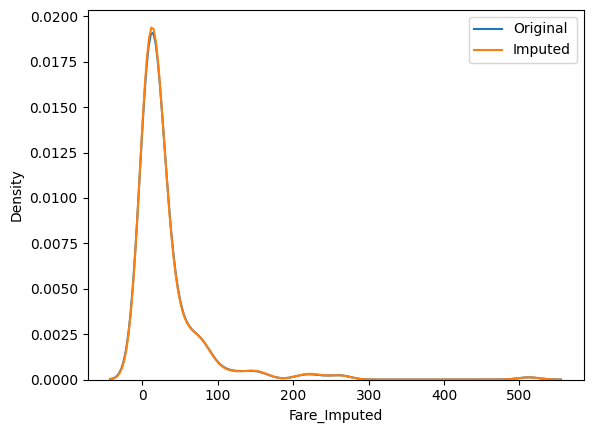

In [100]:
sns.distplot(X_train['Fare'], label='Original', hist=False)
sns.distplot(X_train['Fare_Imputed'], label='Imputed', hist=False)
plt.legend()

In [101]:
print('Original: ', X_train['Fare'].var())
print('Imputed: ', X_train['Fare_Imputed'].var())

Original:  2761.031434948639
Imputed:  2720.884515793594


In [102]:
X_train.cov()

,Age,Fare,Family,Age_Imputed,Fare_Imputed
Age,210.251707,75.481375,-6.993325,210.251707,76.843554
Fare,75.481375,2761.031435,18.599163,62.966016,2761.031435
Family,-6.993325,18.599163,2.830892,-6.091526,17.219666
Age_Imputed,210.251707,62.966016,-6.091526,209.663670,65.237064
Fare_Imputed,76.843554,2761.031435,17.219666,65.237064,2720.884516


<Axes: >

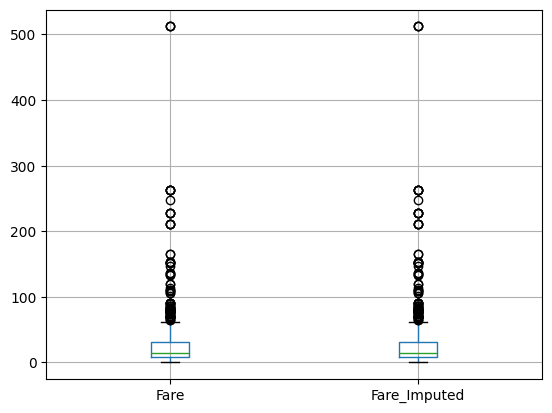

In [103]:
X_train[['Fare','Fare_Imputed']].boxplot()

# Random Imputation - Categorical Values

In [ ]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train['GarageQual_Imputed'] = X_train['GarageQual']
X_train['FireplaceQu_Imputed'] = X_train['FireplaceQu']

In [ ]:
X_train['FireplaceQu_Imputed'][X_train['FireplaceQu_Imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum(), random_state=0).values
X_train['GarageQual_Imputed'][X_train['GarageQual_Imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum(), random_state=0).values

In [ ]:
X_train

,FireplaceQu,GarageQual,GarageQual_Imputed,FireplaceQu_Imputed
254,NaN,TA,TA,TA
1066,TA,TA,TA,TA
638,NaN,NaN,TA,Fa
799,TA,TA,TA,TA
380,Gd,TA,TA,Gd
...,...,...,...,...
1095,Gd,TA,TA,Gd
1130,TA,TA,TA,TA
1294,NaN,TA,TA,Gd
860,Gd,TA,TA,Gd


In [ ]:
temp = pd.concat([X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
                  X_train['GarageQual_Imputed'].value_counts() / len(X_train)], axis=1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
TA,0.951087,0.951199
Fa,0.032609,0.033390
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [ ]:
temp = pd.concat([X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
                  X_train['FireplaceQu_Imputed'].value_counts() / len(X_train)], axis=1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
Gd,0.491143,0.485445
TA,0.405797,0.409247
Fa,0.043478,0.046233
Ex,0.033816,0.032534
Po,0.025765,0.026541


# Missing Indicator

In [ ]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived', axis=1), df['Survived'], test_size=0.2, random_state=42)

In [ ]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()

In [ ]:
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_imputed, y_train)

Y_pred = clf.predict(X_test_imputed)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, Y_pred)

0.6480446927374302

In [ ]:
from sklearn.impute import MissingIndicator
indicator = MissingIndicator()
indicator.fit(X_train)

MissingIndicator()

In [ ]:
X_train_Missing = indicator.transform(X_train)
X_test_Missing = indicator.transform(X_test)

In [ ]:
X_test_Missing

array([[ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [ ]:
X_train['Age_missing'] = X_train_Missing
X_test['Age_missing'] = X_test_Missing

In [ ]:
X_train

,Age,Fare,Age_missing
331,45.5,28.5000,False
733,23.0,13.0000,False
382,32.0,7.9250,False
704,26.0,7.8542,False
813,6.0,31.2750,False
...,...,...,...
106,21.0,7.6500,False
270,NaN,31.0000,True
860,41.0,14.1083,False
435,14.0,120.0000,False


In [ ]:
Si = SimpleImputer()
X_train_imputed = Si.fit_transform(X_train)
X_test_imputed = Si.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_imputed, y_train)

Y_pred = clf.predict(X_test_imputed)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, Y_pred)

0.6368715083798883

# Automatically Select Value for Imputation
## GridSearch CV